In [ ]:
import scanpy as sc
import pandas as pd
import numpy as np
import os
import re
import matplotlib.pyplot as plt
import warnings
import numba
import seaborn as sns
import random
import scipy

sc.set_figure_params(dpi=80)
plt.rcParams["axes.grid"] = False

import matplotlib
matplotlib.rcParams["text.usetex"] = False
matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42
from matplotlib import rc
rc('font',**{'family':'sans-serif','sans-serif':['DejaVu Sans']})

%config InlineBackend.figure_format='retina'


In [ ]:
import importlib.util
import sys

def lazy_import(module_name, path_to_file):
    spec = importlib.util.spec_from_file_location(module_name,path_to_file)
    foo = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = foo
    spec.loader.exec_module(foo)
    return foo

utils_dir = "../../utils"
general_utils =  lazy_import("general_utils",os.path.join(utils_dir, "general_utils.py"))
anndata_utils = lazy_import("anndata_utils",os.path.join(utils_dir, "anndata_utils.py"))
plotting_functions = lazy_import("plotting_functions",os.path.join(utils_dir, "plotting_functions.py"))
thresholding_functions = lazy_import("thresholding_functions",os.path.join(utils_dir, "thresholding_functions.py"))
gene_signatures_utils = lazy_import("gene_signatures_utils",os.path.join(utils_dir, "gene_signatures.py"))
preprocessing_utils = lazy_import("preprocessing_utils",os.path.join(utils_dir, "preprocessing_utils.py"))
diffusion_maps = lazy_import("diffusion_maps",os.path.join(utils_dir, "diffusion_maps.py"))

from general_utils import ismember, grep
from plotting_functions import plot_individual_category, plot_scatter, plot_signature, plot_gene, get_pseudo_colors, pseudo_color
from anndata_utils import marker_genes_for_cell_group, zscore_with_subset, get_gene, get_genes, annotate_groups
from thresholding_functions import threshold_otsu, threshold_triangle, histogram_knee
from gene_signatures_utils import toupper, attach_selected_signatures
from preprocessing_utils import norm_log_transform, HVG_selection, kneepoint, process_pca_results, process_pca_inflection
from diffusion_maps import get_diffusion_operator_from_knn, getDiffusionComponents, plot_diffusion_components, imputeData


### Generate embeddings

Load integrated data and define parameters

In [ ]:
adata = sc.read_h5ad("../data/Reyes_injury_SUBSET_all__integrated.h5ad")

num_HVG = 3000
pca_mode = 'inflection'
layer = 'cellbender'
norm_strategy = 'noExcluded'

In [ ]:
adata.obs['size_factor'] = np.exp(np.ravel(adata.obs['log_lib_size_%s_%s' % (layer, norm_strategy)]))

Embed samples

In [ ]:
adata_sub = adata.copy()
adata.X = adata.layers[layer].copy()
adata_sub = norm_log_transform(adata_sub, adata_sub.obs['size_factor'], [])

sc.pp.filter_cells(adata_sub, min_counts=1)
sc.pp.filter_genes(adata_sub, min_cells=1)

adata_sub = HVG_selection(adata_sub, num_HVG=num_HVG, layer = layer, mode = 'scanpy', exclude_genes= adata_sub.var['excluded'])
sc.pp.pca(adata_sub, n_comps=200, use_highly_variable=True)

Normalizing data
Log transform with pseudocount 1
Highly variable gene selection with custom gene exclusion
Selecting 3000 highly variable genes using Scanpy Seurat v3
Using 3000 highly variable genes


Detecting inflection point with average smoothing window of 10 and epsilon 0.000010


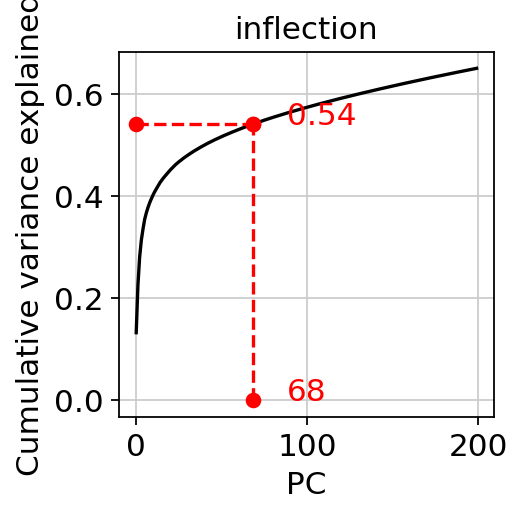

In [ ]:
selected_pcs, explained_var = process_pca_results(adata_sub, pca_mode = pca_mode, epsilon = 0.00001)
adata_sub.obsm['X_pca'] = adata_sub.obsm['X_pca'][:,:selected_pcs].copy()

In [ ]:
sc.pp.neighbors(adata_sub, n_neighbors=30)
sc.tl.umap(adata_sub)
communities = sc.external.tl.phenograph(adata_sub, k=30, clustering_algo = 'leiden', seed = 0, copy=True)
adata_sub.obs['pheno_30'] = pd.Categorical(communities[0])
communities = sc.external.tl.phenograph(adata_sub, k=10, clustering_algo = 'leiden', seed = 0, copy=True)
adata_sub.obs['pheno_10'] = pd.Categorical(communities[0])

/data/lowe/reyesj3/miniconda3/envs/rpy2/lib/python3.8/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Finding 30 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 1.78312349319458 seconds
Jaccard graph constructed in 6.94113826751709 seconds
Running Leiden optimization
Leiden completed in 1.90549635887146 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 14.71831202507019 seconds
Finding 10 nearest neighbors using minkowski metric and 'auto' algorithm
Neighbors computed in 1.4105253219604492 seconds
Jaccard graph constructed in 4.662771701812744 seconds
Running Leiden optimization
Leiden completed in 1.5731408596038818 seconds
Sorting communities by size, please wait ...
PhenoGraph completed in 11.337454557418823 seconds


/data/lowe/reyesj3/miniconda3/envs/rpy2/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  cax = scatter(


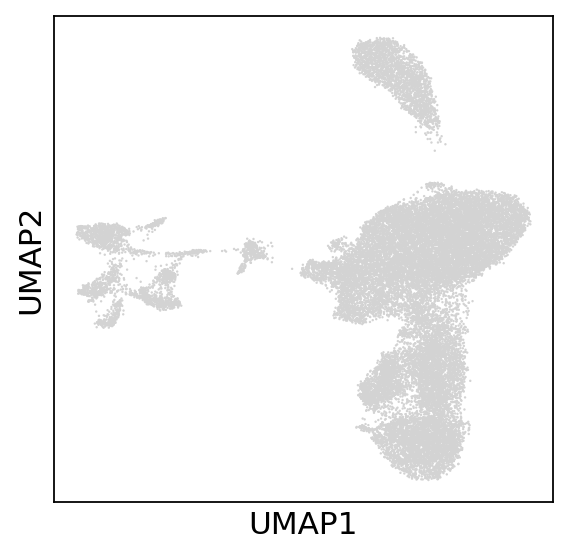

In [ ]:
sc.pl.umap(adata_sub)

Force directed llayout computation

In [ ]:
sc.tl.draw_graph(adata_sub, init_pos="X_umap")

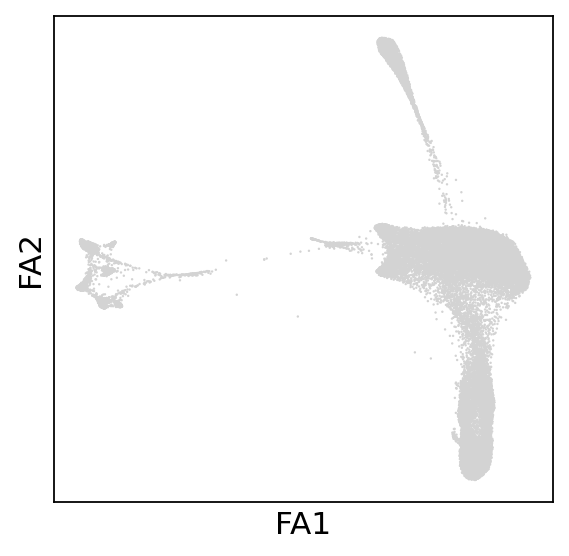

In [ ]:
sc.pl.draw_graph(adata_sub)

### Diffusion components

In [ ]:
distances = adata_sub.obsp['distances']
indices = (distances > 0).astype(np.uint8)
T, kernel = get_diffusion_operator_from_knn(indices, distances)
dm_res = getDiffusionComponents(T, kernel)
adata_sub.obsm['X_diff_comp'] = dm_res['EigenVectors'].to_numpy()[:,1:].copy()
adata_sub.uns['diff_comp_eigenvalues'] = dm_res['EigenValues'].to_numpy()[1:].copy()
adata_sub.obsp['diffusion_operator'] = dm_res['T'].copy()
adata_sub.obsp['affinity_matrix'] = dm_res['kernel'].copy()


Computing diffusion kernel using CPU
Computing diffusion operator using CPU


Identify gastric-progenitor DC

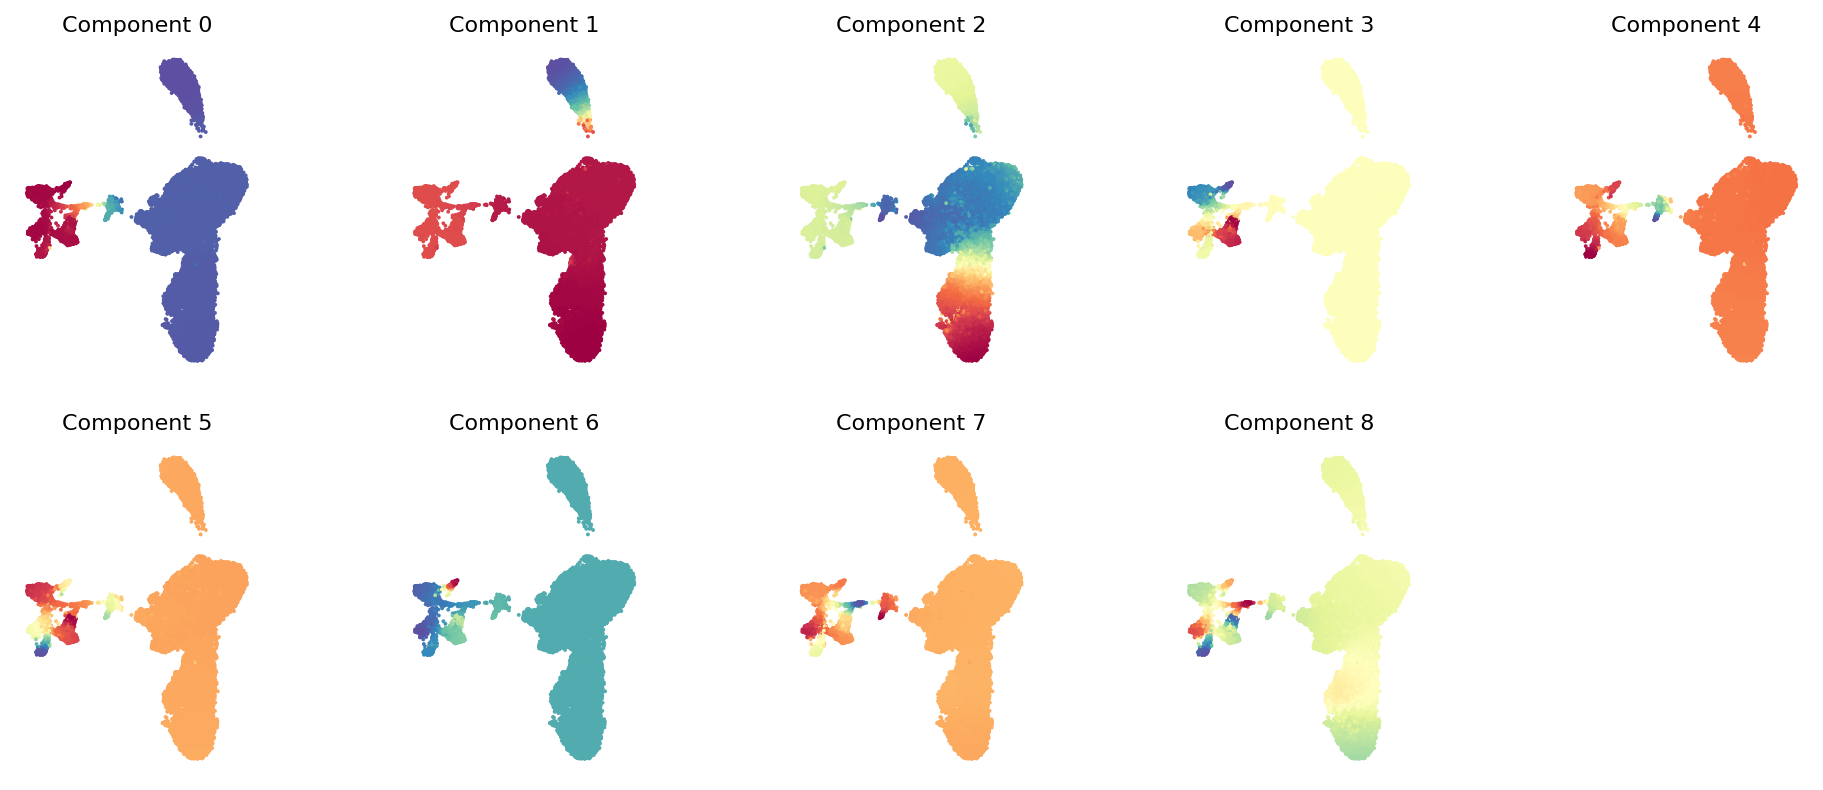

In [ ]:
plot_diffusion_components(adata_sub.obsm["X_umap"], adata_sub.obsm["X_diff_comp"])

In [ ]:
adata_sub.obs['DC_gastric_progenitor'] = np.ravel(adata_sub.obsm['X_diff_comp'][:,2])
adata_sub.obs['DC_progenitor1_progenitor2'] = -np.ravel(adata_sub.obsm['X_diff_comp'][:,8])

### Annotate cell types

In [ ]:
adata = adata_sub.copy()

Create a temporary object with standardized counts for computing gene signatures

In [ ]:
# Z-score and add signature scores
adata_temp = adata.copy()
adata_temp.layers['zscore'] = adata_temp.X.copy()
sc.pp.scale(adata_temp, layer='zscore')

Compute gene signatures of premalignant states

In [ ]:
selected_signatures = [
    'ADM_specific_0', 'gastric_specific_0', 'neuroendocrine_specific_0', 
    'progenitor_specific_0', 'tuft_specific_30'
]
attach_selected_signatures(adata_temp, '../signatures/', selected_signatures)

100%|██████████| 5/5 [00:00<00:00, 32.19it/s]


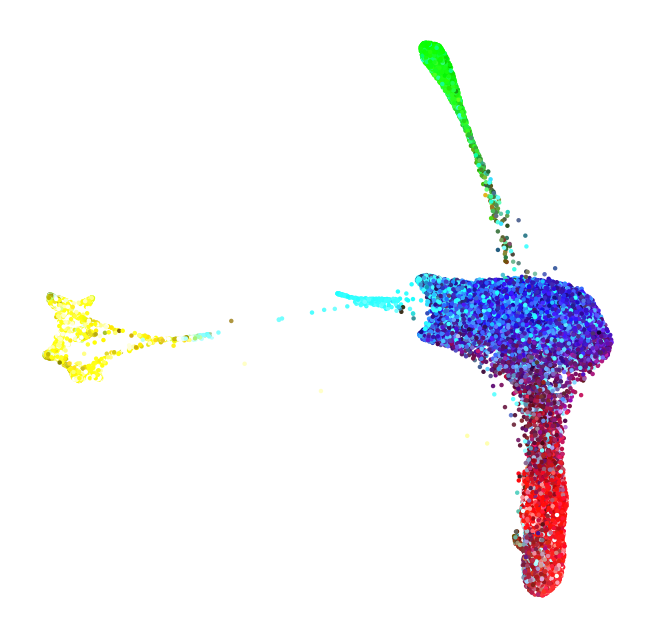

In [ ]:
selected_colors = [[0,1,0], [0,0,1], [1,1,0], [1,0,0], [0,1,1]]
pseudo_color(adata_temp, 'X_draw_graph_fa', selected_signatures, selected_colors, figsize = (5,5), s = 1)
plt.grid(False)
h = plt.axis(False)


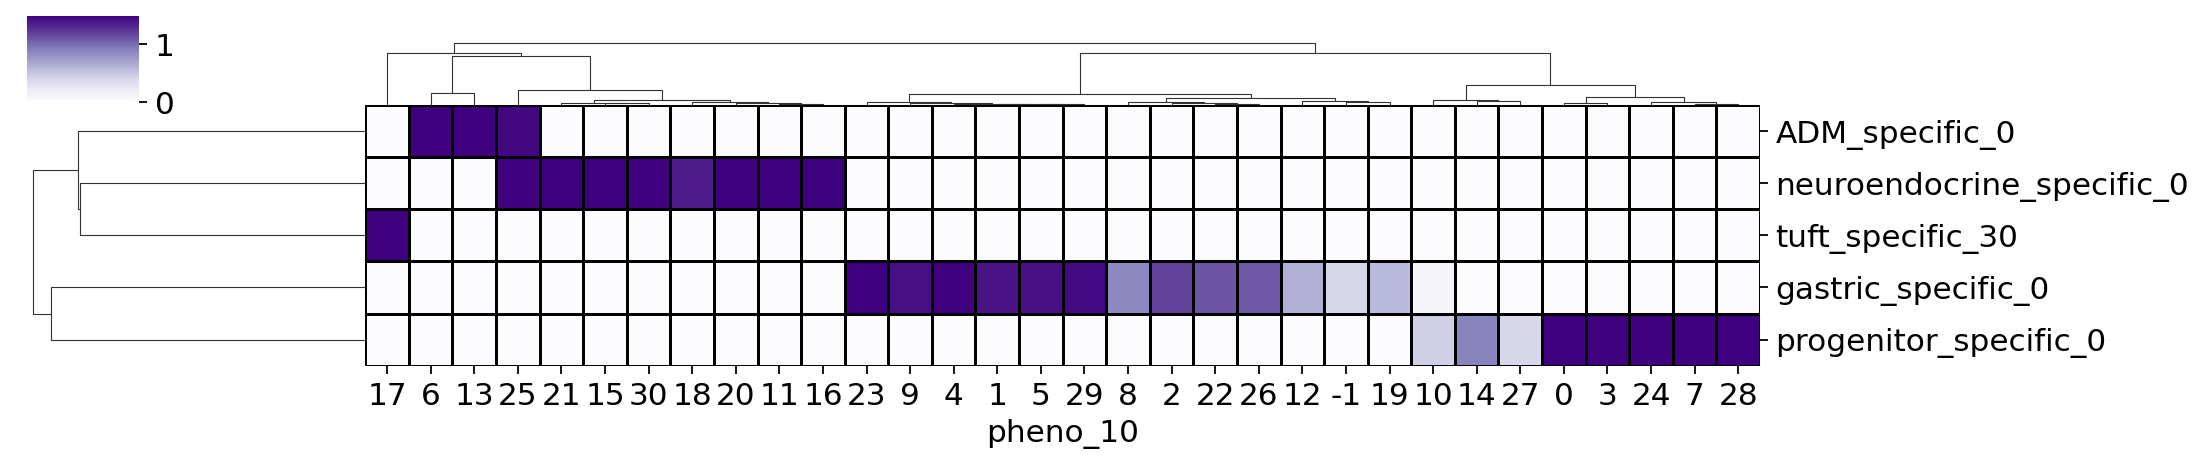

In [ ]:
df = adata_temp.obs[selected_signatures + ['pheno_10']].groupby('pheno_10').agg('mean')
df = df - df.mean(axis=0)
df = df / np.std(df, axis=0)
sns.clustermap(df.T, figsize=[14,3], method='ward', dendrogram_ratio=0.2, cmap='Purples', linewidths = 0.5, vmin=0, vmax=1.5, linecolor='black')


/data/lowe/reyesj3/miniconda3/envs/rpy2/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


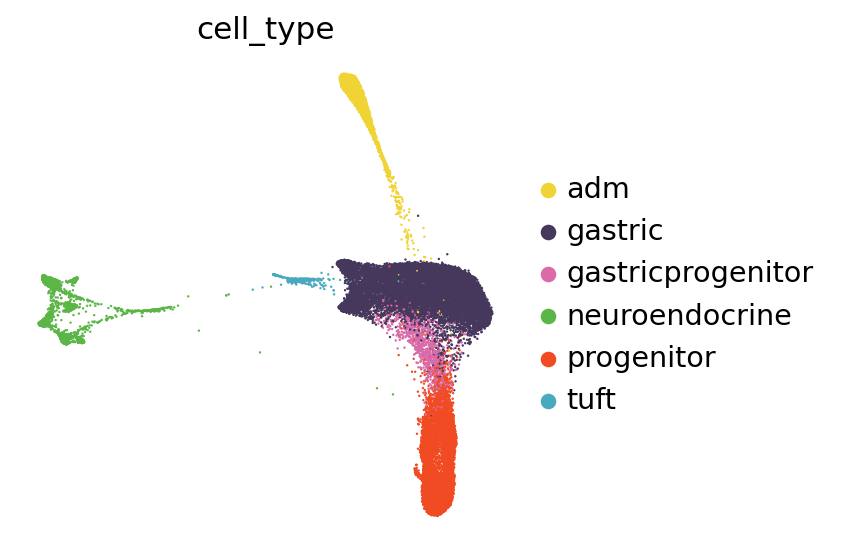

In [ ]:
cell_type = np.array(['undefined'] * adata.n_obs, dtype=object)

cell_type[ismember(adata.obs['pheno_10'], [6,13])[1]] = 'adm'
cell_type[ismember(adata.obs['pheno_10'], [17])[1]] = 'tuft'
cell_type[ismember(adata.obs['pheno_10'], [25,21,15,30,18,20,11,16])[1]] = 'neuroendocrine'
cell_type[ismember(adata.obs['pheno_10'], [0,3,24,7,28,14])[1]] = 'progenitor'
cell_type[ismember(adata.obs['pheno_10'], [23,9,4,1,5,29,8,2,22,26,12,-1,19])[1]] = 'gastric'
cell_type[ismember(adata.obs['pheno_10'], [10,27])[1]] = 'gastricprogenitor'

adata.obs['cell_type'] = cell_type.copy()
cell_type_palette = ['#F0D335', '#46375C', '#DA6AA9', '#5CB647', '#F04B23', '#48A9BF']
sc.pl.draw_graph(adata, color='cell_type', layout = 'fa', palette = cell_type_palette, frameon=False)

#### Use PhenoGraph clusters to refine progenitor annotation

/data/lowe/reyesj3/miniconda3/envs/rpy2/lib/python3.8/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


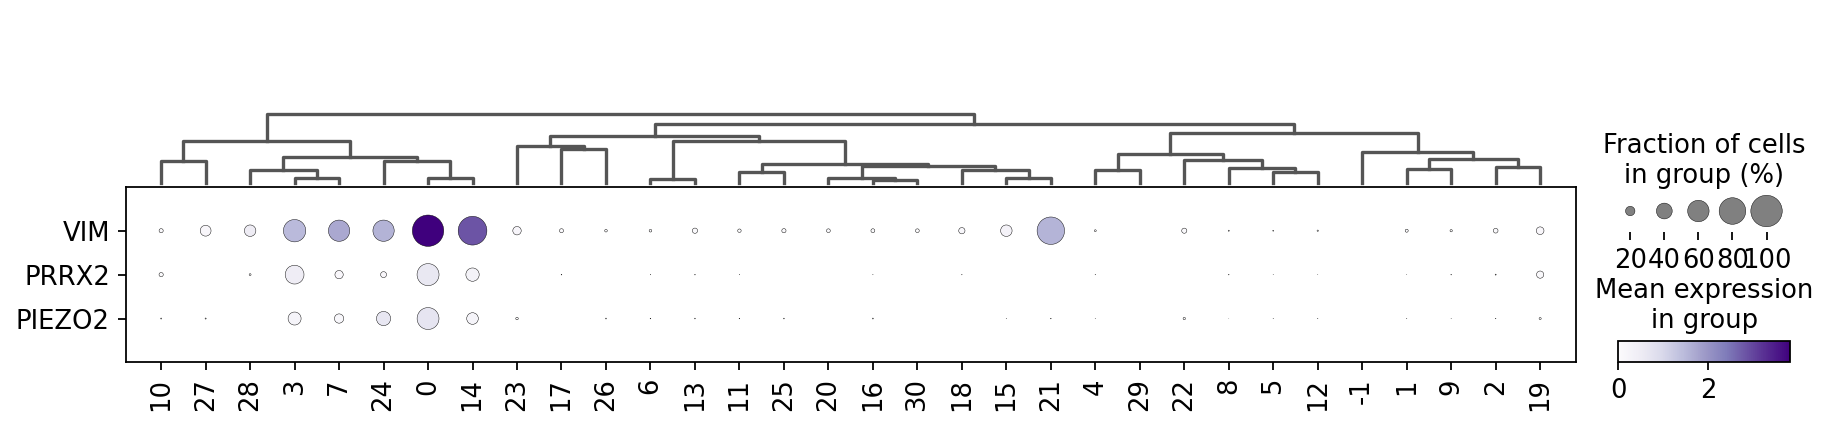

In [ ]:
sc.pl.dotplot(adata, groupby = 'pheno_10', var_names = ['VIM', 'PRRX2', 'PIEZO2'], swap_axes = True, dendrogram = True, cmap = 'Purples')

/data/lowe/reyesj3/miniconda3/envs/rpy2/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


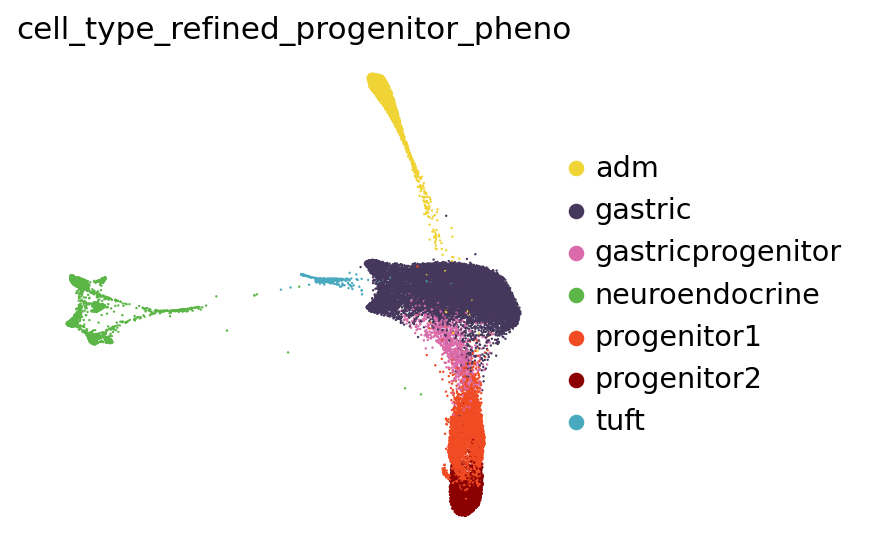

In [ ]:
cell_type = np.array(['undefined'] * adata.n_obs, dtype=object)

cell_type[ismember(adata.obs['pheno_10'], [6,13])[1]] = 'adm'
cell_type[ismember(adata.obs['pheno_10'], [17])[1]] = 'tuft'
cell_type[ismember(adata.obs['pheno_10'], [25,21,15,30,18,20,11,16])[1]] = 'neuroendocrine'
cell_type[ismember(adata.obs['pheno_10'], [3,24,7,28,14])[1]] = 'progenitor1'
cell_type[ismember(adata.obs['pheno_10'], [0])[1]] = 'progenitor2'
cell_type[ismember(adata.obs['pheno_10'], [23,9,4,1,5,29,8,2,22,26,12,-1,19])[1]] = 'gastric'
cell_type[ismember(adata.obs['pheno_10'], [10,27])[1]] = 'gastricprogenitor'

adata.obs['cell_type_refined_progenitor_pheno'] = cell_type.copy()
cell_type_palette = ['#F0D335', '#46375C', '#DA6AA9', '#5CB647', '#F04B23', 'darkred', '#48A9BF']
sc.pl.draw_graph(adata, color='cell_type_refined_progenitor_pheno', layout = 'fa', palette = cell_type_palette, frameon=False)

#### Refine progenitor annotation using diffusion components

In [ ]:
adata_temp = adata.copy()
imputed_data = imputeData(adata_temp, adata_temp.obsp['diffusion_operator'], n_steps=3)
adata_temp.layers['imputed'] = imputed_data.copy()

Threshold Vim expression distribution to identify Vim+ cells

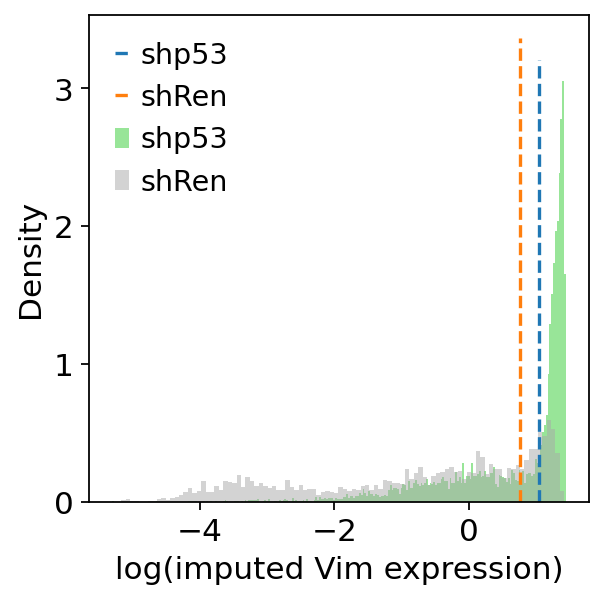

In [ ]:
condition_filter = ismember(adata_temp.obs['cell_type'], ['progenitor', 'gastricprogenitor'])[1]

subcells = adata_temp.obs['genotype'] == 'shp53'
subcells = np.logical_and(subcells, condition_filter)
h = plt.hist(np.log(get_gene(adata_temp[subcells,:], "VIM", layer='imputed')), bins=250, density=True, alpha=0.5, color='limegreen')
current_knee = histogram_knee(h, plot=False)
knee_shp53 = np.exp(h[1][current_knee])
plt.plot([h[1][current_knee]] * 2, plt.gca().get_ylim(), '--')

subcells = adata_temp.obs['genotype'] == 'shRen'
subcells = np.logical_and(subcells, condition_filter)
h = plt.hist(np.log(get_gene(adata_temp[subcells,:], "VIM", layer='imputed')), bins=100, density=True, alpha=0.5, color='darkgray')
current_knee = histogram_knee(h, plot=False)
knee_shRen = np.exp(h[1][current_knee])
plt.plot([h[1][current_knee]] * 2, plt.gca().get_ylim(), '--')

plt.xlabel('log(imputed Vim expression)')
plt.ylabel('Density')
plt.legend(['shp53', 'shRen', 'shp53', 'shRen'], frameon=False)
plt.grid(False)


Threshold gastric-progenitor DC based on Vim expression

Text(0, 0.5, 'Imputed Vim expression')

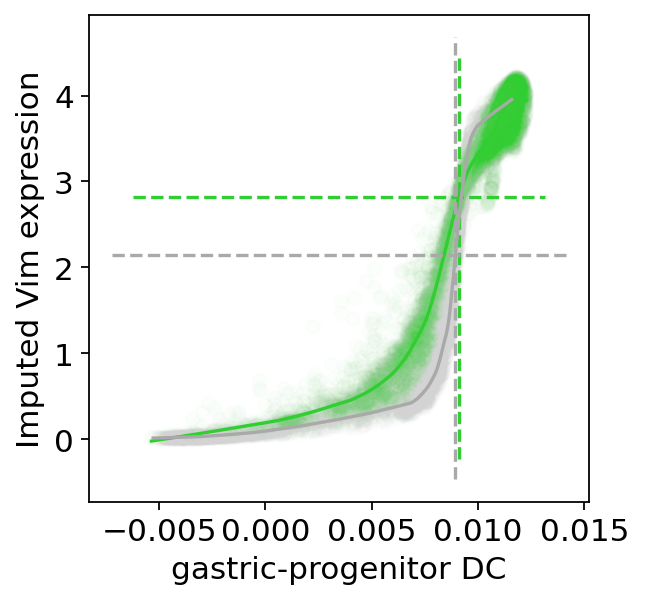

In [ ]:
import statsmodels.api as statsmodels

condition_filter = ismember(adata_temp.obs['cell_type'], ['progenitor', 'gastricprogenitor'])[1]

subcells = adata_temp.obs['genotype'] == 'shp53'
subcells = np.logical_and(subcells, condition_filter)
x = adata_temp[subcells,:].obs['DC_gastric_progenitor']
y = get_gene(adata_temp[subcells,:], "VIM", layer='imputed')

output = statsmodels.nonparametric.lowess(y, x, frac=0.1, return_sorted=True)
plt.scatter(x,y,alpha=0.01,edgecolor=None,c='limegreen')
plt.plot(output[:,0], output[:,1], color='limegreen')
plt.plot(plt.gca().get_xlim(), [knee_shp53, knee_shp53], '--', color='limegreen')
DC_shp53 = output[np.min(np.where(output[:,1] > knee_shp53)[0]),0]
plt.plot([DC_shp53, DC_shp53], plt.gca().get_ylim(), '--', color='limegreen')

subcells = adata_temp.obs['genotype'] == 'shRen'
subcells = np.logical_and(subcells, condition_filter)
x = adata_temp[subcells,:].obs['DC_gastric_progenitor']
y = get_gene(adata_temp[subcells,:], "VIM", layer='imputed')

output = statsmodels.nonparametric.lowess(y, x, frac=0.1, return_sorted=True)
plt.scatter(x,y,alpha=0.01,edgecolor=None,c='lightgray')
plt.plot(output[:,0], output[:,1], color='darkgray')
plt.plot(plt.gca().get_xlim(), [knee_shRen, knee_shRen], '--', color='darkgray')
DC_shRen = output[np.min(np.where(output[:,1] > knee_shRen)[0]),0]
plt.plot([DC_shRen, DC_shRen], plt.gca().get_ylim(), '--', color='darkgray')

plt.grid(False)
plt.xlabel("gastric-progenitor DC")
plt.ylabel('Imputed Vim expression')


In [ ]:
adata.obs['DC3_progenitor2'] = pd.Categorical(np.logical_and(adata.obs['DC_gastric_progenitor'] >= DC_shp53, adata.obs['cell_type'] == 'progenitor'))


Use DC9 to get alternative view of Vim expression in shp53 samples

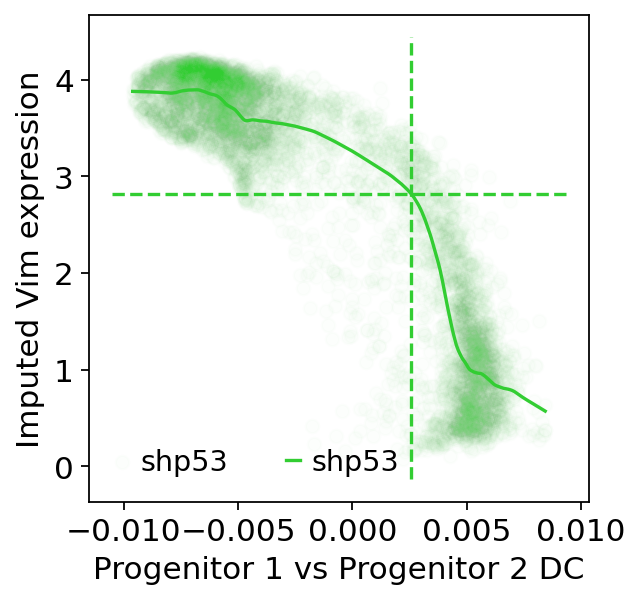

In [ ]:
import statsmodels.api as statsmodels

condition_filter = ismember(adata_temp.obs['cell_type'], ['progenitor'])[1]

subcells = adata_temp.obs['genotype'] == 'shp53'
subcells = np.logical_and(subcells, condition_filter)
x = -np.ravel(adata_temp[subcells,:].obs['DC_progenitor1_progenitor2'])
y = get_gene(adata_temp[subcells,:], "VIM", layer='imputed')

output = statsmodels.nonparametric.lowess(y, x, frac=0.1, return_sorted=True)
plt.scatter(x,y,alpha=0.01,edgecolor=None,c='limegreen')
plt.plot(output[:,0], output[:,1], color='limegreen')
plt.plot(plt.gca().get_xlim(), [knee_shp53, knee_shp53], '--', color='limegreen')
DC_shp53 = output[np.max(np.where(output[:,1] > knee_shp53)[0]),0]
plt.plot([DC_shp53, DC_shp53], plt.gca().get_ylim(), '--', color='limegreen')

plt.grid(False)
plt.xlabel("Progenitor 1 vs Progenitor 2 DC")
plt.ylabel('Imputed Vim expression')
plt.legend(['shp53', 'shp53'], frameon=False, ncol=2)


In [ ]:
adata.obs['DC9_progenitor2'] = pd.Categorical(np.logical_and(adata.obs['DC_progenitor1_progenitor2'] >= DC_shp53, adata.obs['cell_type'] == 'progenitor'))
DC_progenitor_2 = pd.Categorical(np.logical_or(adata.obs['DC3_progenitor2']==True, adata.obs['DC9_progenitor2']==True))

In [ ]:
cell_type_refined_progenitor_pheno = adata.obs['cell_type'].to_numpy()
cell_type_refined_progenitor_pheno[adata.obs['cell_type'] == 'progenitor'] = 'progenitor1'
cell_type_refined_progenitor_pheno[DC_progenitor_2] = 'progenitor2'
adata.obs['cell_type_refined_progenitor_DC'] = cell_type_refined_progenitor_pheno.copy()

#### Identify progenitor PhenoGraph clusters shared between shRen and shp53 samples

/data/lowe/reyesj3/miniconda3/envs/rpy2/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(
/data/lowe/reyesj3/miniconda3/envs/rpy2/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


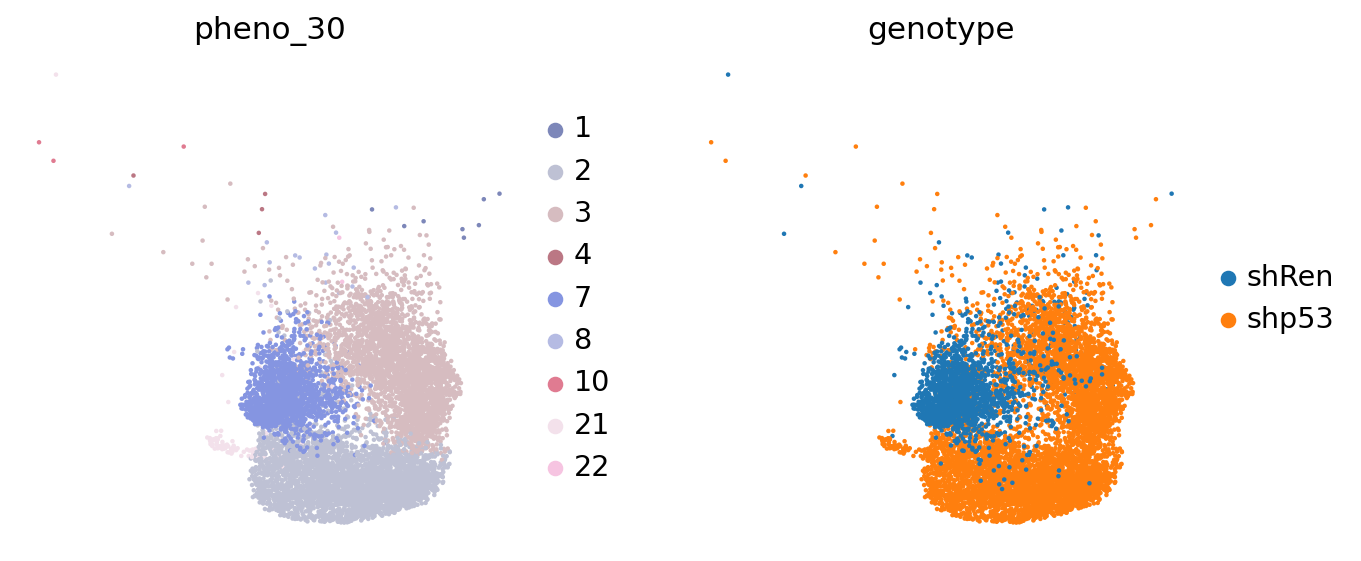

In [ ]:
adata_sub = adata[adata.obs['cell_type'] == 'progenitor',:].copy()
adata_sub.obs['pheno_30'] = pd.Categorical(adata_sub.obs['pheno_30'])
sc.pl.draw_graph(adata_sub, color=['pheno_30', 'genotype'], layout='fa', frameon=False)

/data/lowe/reyesj3/miniconda3/envs/rpy2/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


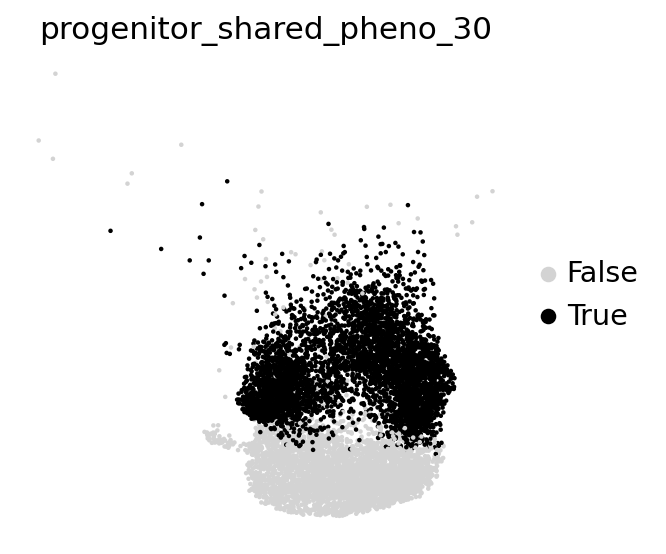

/data/lowe/reyesj3/miniconda3/envs/rpy2/lib/python3.8/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


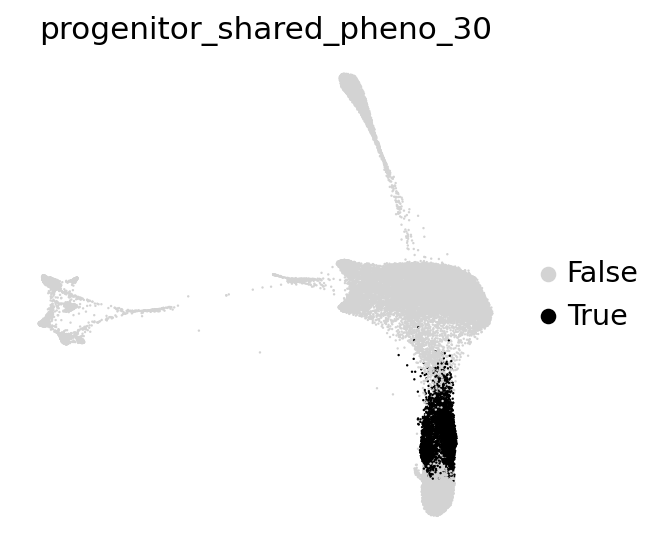

In [ ]:
progenitor_filter = adata_sub.obs['cell_type'] == 'progenitor'
shared_filter = ismember(adata_sub.obs['pheno_30'], [3,7])[1]
adata_sub.obs['progenitor_shared_pheno_30'] = pd.Categorical(np.logical_and(progenitor_filter, shared_filter))
sc.pl.draw_graph(adata_sub, color='progenitor_shared_pheno_30', layout='fa', palette = ['lightgray', 'black'], frameon=False)

adata.obs['progenitor_shared_pheno_30'] = pd.Categorical(ismember(adata.obs_names, adata_sub.obs_names[adata_sub.obs['progenitor_shared_pheno_30'] == True])[1])
sc.pl.draw_graph(adata, color='progenitor_shared_pheno_30', layout='fa', palette = ['lightgray', 'black'], frameon=False)


In [ ]:
adata.obs['progenitor_all'] = pd.Categorical(adata.obs['cell_type'] == 'progenitor')

In [ ]:
outputFile = "../data/Reyes_injury_SUBSET_all__annotated.h5ad"
sc.write(filename = outputFile, adata = adata)

### Save final matrix

In [ ]:
outputFile = "../data/Reyes_injury_SUBSET_all__annotated.h5ad"
if not os.path.exists(outputFile):
    sc.write(filename = outputFile, adata = adata)


### Pseudobulk matrices

Here, I compute pseudobulk matrices of unnormalized cellbender corrected counts, grouping cells by combinations meta data

In [ ]:
def get_output_path(groupby):
    group_str = '_'.join(groupby)
    output_path = os.path.join(differential_expression_path, file_code, group_str)
    os.makedirs(output_path, exist_ok=True)
    return(output_path)
    
def compile_pseudobulk_counts(adata, groupby):
    output_path = get_output_path(groupby)

    df = pd.DataFrame(np.array(adata.layers['cellbender'].todense()), index = adata.obs_names)
    df.columns = adata.var_names
    df = pd.concat((df, adata.obs[groupby]), axis = 1)
    
    df_agg = df.groupby(groupby, observed=True).agg('sum')
    df_agg.index = df_agg.index.to_flat_index()
    
    current_index = ['_'.join([str(x0) + '_' + str(y0) for x0,y0 in zip(groupby,y)]) for y in df_agg.index]
    df_agg.index = current_index
    
    df_agg.T.to_csv(os.path.join(output_path, 'cellbender_counts_pseudobulk.csv'))

In [ ]:
differential_expression_path = "../differential_expression/"
file_code = "injury_shp53"
adata_sub = adata[adata.obs['hash_id'] != 'undefined'].copy()

In [ ]:
groupby = ['cell_type', 'genotype', 'replicate_id']
compile_pseudobulk_counts(adata_sub, groupby)

In [ ]:
groupby = ['cell_type_refined_progenitor_pheno', 'genotype', 'replicate_id']
compile_pseudobulk_counts(adata_sub, groupby)

In [ ]:
groupby = ['progenitor_all', 'genotype', 'replicate_id']
compile_pseudobulk_counts(adata_sub, groupby)

In [ ]:
groupby = ['progenitor_shared_pheno_30', 'genotype', 'replicate_id']
compile_pseudobulk_counts(adata_sub, groupby)

### Differential gene expression

In [ ]:
import rpy2
from rpy2.robjects import pandas2ri
import rpy2.robjects as robjects
pandas2ri.activate()

%load_ext rpy2.ipython

The rpy2.ipython extension is already loaded. To reload it, use:
  %reload_ext rpy2.ipython


In [ ]:
def read_R_data_frame(r_command):
    my_data_frame = robjects.r(r_command)
    df = pd.DataFrame.from_dict({ key : np.asarray(my_data_frame.rx2(key)) for key in my_data_frame.names })
    return(df)

shp53 progenitor 2 vs shp53 progenitor 1

In [ ]:
groupby = ['cell_type_refined_progenitor_pheno', 'genotype', 'replicate_id']
input_path = get_output_path(groupby)
df = pd.read_csv(os.path.join(input_path, 'cellbender_counts_pseudobulk.csv'), index_col = 0)

metadata_extractor = '_'.join([x + '_(.*)' for x in groupby])
metadata = pd.DataFrame([re.findall(metadata_extractor, x)[0] for x in df.columns], index = df.columns, columns = groupby)
np.unique(metadata[groupby[0]])

array(['adm', 'gastric', 'gastricprogenitor', 'neuroendocrine',
       'progenitor1', 'progenitor2', 'tuft'], dtype=object)

In [ ]:
cell_type_column = groupby[0]
genotype_column = 'genotype'

cell_types = ['progenitor2', 'progenitor1']
genotypes = ['shp53']

valid_columns = np.logical_and(
    ismember(metadata[cell_type_column], cell_types)[1], 
    ismember(metadata[genotype_column], genotypes)[1]
)

df = df.loc[:,valid_columns].copy()
metadata = metadata.loc[valid_columns,:].copy()

In [ ]:
filtering_str = cell_type_column + '__' + '_'.join(cell_types) + '__' + genotype_column + '__' + '_'.join(genotypes)
print(filtering_str)

cell_type_refined_progenitor_pheno__progenitor2_progenitor1__genotype__shp53


In [ ]:
df_r = pandas2ri.py2rpy_pandasdataframe(df)
metadata_r = pandas2ri.py2rpy_pandasdataframe(metadata)

query = cell_types[1]
reference = cell_types[0]

In [ ]:
%%R -i df_r,metadata_r,cell_type_column,query,reference
library(DESeq2)

print(cell_type_column)
print(query)
print(reference)

dds <- DESeqDataSetFromMatrix(countData = df_r, colData = metadata_r, design= as.formula(sprintf("~ %s", cell_type_column)))
keep <- rowSums(counts(dds) >= 10) >= 2
dds <- dds[keep,]
dds <- DESeq(dds)
res <- data.frame(results(dds, contrast = c(cell_type_column, query, reference)))

[1] "cell_type_refined_progenitor_pheno"
[1] "progenitor1"
[1] "progenitor2"


R[write to console]: converting counts to integer mode

R[write to console]: estimating size factors

R[write to console]: estimating dispersions

R[write to console]: gene-wise dispersion estimates

R[write to console]: mean-dispersion relationship

R[write to console]: final dispersion estimates

R[write to console]: fitting model and testing



In [ ]:
res = robjects.r('res')
res.to_csv(os.path.join(input_path, 'DESEQ20260204_FILTER__%s__CONTRAST__%s_vs_%s.csv' % (filtering_str, query, reference)))


Progenitor shared: shp53 vs shRen

In [ ]:
groupby = ['progenitor_shared_pheno_30', 'genotype', 'replicate_id']
input_path = get_output_path(groupby)
df = pd.read_csv(os.path.join(input_path, 'cellbender_counts_pseudobulk.csv'), index_col = 0)

metadata_extractor = '_'.join([x + '_(.*)' for x in groupby])
metadata = pd.DataFrame([re.findall(metadata_extractor, x)[0] for x in df.columns], index = df.columns, columns = groupby)
np.unique(metadata[groupby[0]])

array(['False', 'True'], dtype=object)

In [ ]:
cell_type_column = groupby[0]
genotype_column = 'genotype'

cell_types = ['True']
genotypes = ['shp53', 'shRen']

valid_columns = np.logical_and(
    ismember(metadata[cell_type_column], cell_types)[1], 
    ismember(metadata[genotype_column], genotypes)[1]
)
df = df.loc[:,valid_columns].copy()
metadata = metadata.loc[valid_columns,:].copy()


In [ ]:
filtering_str = cell_type_column + '__' + '_'.join(cell_types) + '__' + genotype_column + '__' + '_'.join(genotypes)
print(filtering_str)

df_r = pandas2ri.py2rpy_pandasdataframe(df)
metadata_r = pandas2ri.py2rpy_pandasdataframe(metadata)

query = genotypes[0]
reference = genotypes[1]

progenitor_shared_pheno_30__True__genotype__shp53_shRen


In [ ]:
%%R -i df_r,metadata_r,cell_type_column,query,reference
library(DESeq2)

print(cell_type_column)
print(query)
print(reference)

dds <- DESeqDataSetFromMatrix(countData = df_r, colData = metadata_r, design= ~ genotype)
# Exclude genes that don't have at least 10 counts in at least two pseudobulk replicates
keep <- rowSums(counts(dds) >= 10) >= 2
dds <- dds[keep,]
dds <- DESeq(dds)
res_shp53 <- data.frame(results(dds, contrast = c("genotype", "shp53", "shRen")))

[1] "progenitor_shared_pheno_30"
[1] "shp53"
[1] "shRen"


R[write to console]: converting counts to integer mode

R[write to console]: estimating size factors

R[write to console]: estimating dispersions

R[write to console]: gene-wise dispersion estimates

R[write to console]: mean-dispersion relationship

R[write to console]: final dispersion estimates

R[write to console]: fitting model and testing



In [ ]:
res_shp53 = robjects.r('res_shp53')
res_shp53.to_csv(os.path.join(input_path, 'DESEQ20260104_FILTER__%s__CONTRAST__shp53_vs_shRen.csv' % (filtering_str)))
